In [1]:
print('hel;lo world')

hel;lo world


In [2]:
import pandas as pd
import xgboost as xgb
import numpy as np
import sklearn
import optuna

print("XGBoost Version", xgb.__version__)
print("Pandas Version", pd.__version__)
print("Numpy Version", np.__version__)
print("Sklearn Version", sklearn.__version__)
print("Optuna Version", optuna.__version__)

XGBoost Version 3.2.0
Pandas Version 3.0.3
Numpy Version 2.4.6
Sklearn Version 1.8.0
Optuna Version 4.8.0


d:\Coding\LinearRegInPython\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("life.csv")
df = df.dropna(subset=["Life expectancy "]).copy()
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
COLS_TO_DROP = ["Year", "Status", "Country", "Life expectancy "]

X = df[[c for c in df.columns if c not in COLS_TO_DROP]]
y = df["Life expectancy "]

In [5]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_validate
import optuna


# Defining the objective function
def objective_gpu(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
    }

    model = xgb.XGBRegressor(**param, device="cuda")

    scores = cross_validate(
        model,
        X,
        y,
        cv=GroupKFold(n_splits=3),
        groups=df["Country"],
        scoring={
            "mae": "neg_mean_absolute_error",
            "mape": "neg_mean_absolute_percentage_error",
        },
        error_score="raise",
    )

    fold_mapes = -scores["test_mape"] * 100
    print(f"Fold MAPE (%): {fold_mapes}")
    print(f"Mean MAPE (%): {fold_mapes.mean():.2f}")

    return scores["test_mae"].mean()

In [6]:
# Create and run the optimization process with 10 trials
study = optuna.create_study(study_name="xgboost_study_cuda", direction="maximize")
study.optimize(objective_gpu, n_trials=10, show_progress_bar=True, n_jobs=-1)

# Retrieve the best parameter values
best_params = study.best_params
print(f"\nBest parameters: {best_params}")

[I 2026-05-25 22:40:06,144] A new study created in memory with name: xgboost_study_cuda
Best trial: 4. Best value: -2.0041:  10%|█         | 1/10 [00:07<01:08,  7.65s/it]

Fold MAPE (%): [3.27052484 3.15654374 2.74192772]
Mean MAPE (%): 3.06
[I 2026-05-25 22:40:13,792] Trial 4 finished with value: -2.0041031165201155 and parameters: {'max_depth': 7, 'learning_rate': 0.09442925881117395, 'n_estimators': 107, 'subsample': 0.8989046329031195, 'colsample_bytree': 0.6452613096427662, 'min_child_weight': 6, 'gamma': 4.5448689313805}. Best is trial 4 with value: -2.0041031165201155.


Best trial: 4. Best value: -2.0041:  20%|██        | 2/10 [00:20<01:26, 10.78s/it]

Fold MAPE (%): [3.54237688 3.13519256 2.68384644]
Mean MAPE (%): 3.12
[I 2026-05-25 22:40:26,773] Trial 9 finished with value: -2.032291056419331 and parameters: {'max_depth': 9, 'learning_rate': 0.02466291087674978, 'n_estimators': 163, 'subsample': 0.8564863397542276, 'colsample_bytree': 0.668841191928933, 'min_child_weight': 8, 'gamma': 2.3452773657258383}. Best is trial 4 with value: -2.0041031165201155.


Best trial: 4. Best value: -2.0041:  30%|███       | 3/10 [00:22<00:47,  6.85s/it]

...

Fold MAPE (%): [3.32406849 3.19086024 2.67377225]
Mean MAPE (%): 3.06
[I 2026-05-25 22:40:37,615] Trial 2 finished with value: -2.0037967650616757 and parameters: {'max_depth': 8, 'learning_rate': 0.06154268722051952, 'n_estimators': 921, 'subsample': 0.6511724568751514, 'colsample_bytree': 0.675067928318748, 'min_child_weight': 5, 'gamma': 3.9230647987026894}. Best is trial 0 with value: -1.9679535550497917.
Fold MAPE (%): [3.35948899 3.17060313 2.80247702]
Mean MAPE (%): 3.11
[I 2026-05-25 22:40:37,717] Trial 5 finished with value: -2.0410767523968807 and parameters: {'max_depth': 7, 'learning_rate': 0.045068456623654454, 'n_estimators': 910, 'subsample': 0.9461621563073483, 'colsample_bytree': 0.9904129588309755, 'min_child_weight': 3, 'gamma': 3.5904576280225498}. Best is trial 0 with value: -1.9679535550497917.


Best trial: 0. Best value: -1.96795:  90%|█████████ | 9/10 [00:32<00:01,  1.81s/it]

Fold MAPE (%): [3.2720852  3.15852415 2.93068011]
Mean MAPE (%): 3.12
[I 2026-05-25 22:40:38,421] Trial 3 finished with value: -2.039458430139094 and parameters: {'max_depth': 6, 'learning_rate': 0.0720544634586082, 'n_estimators': 964, 'subsample': 0.6897427866547223, 'colsample_bytree': 0.6374628024617044, 'min_child_weight': 2, 'gamma': 1.3854745469577727}. Best is trial 0 with value: -1.9679535550497917.


Best trial: 0. Best value: -1.96795: 100%|██████████| 10/10 [00:33<00:00,  3.31s/it]

Fold MAPE (%): [3.32141348 3.12002039 2.7666056 ]
Mean MAPE (%): 3.07
[I 2026-05-25 22:40:39,216] Trial 8 finished with value: -2.0097488674309734 and parameters: {'max_depth': 8, 'learning_rate': 0.027739098395055783, 'n_estimators': 847, 'subsample': 0.5662197845282508, 'colsample_bytree': 0.7254172644147736, 'min_child_weight': 1, 'gamma': 2.8337435513930602}. Best is trial 0 with value: -1.9679535550497917.

Best parameters: {'max_depth': 6, 'learning_rate': 0.0613597937562358, 'n_estimators': 718, 'subsample': 0.8731618466259028, 'colsample_bytree': 0.740134571579173, 'min_child_weight': 2, 'gamma': 2.636238756765801}


In [7]:
study.best_value

-1.9679535550497917

In [8]:
best_model = xgb.XGBRegressor(**best_params, device="cuda")
best_model.fit(X, y)
predictions = best_model.predict(X)
predictions[40:2000:200], y[40:2000:200], predictions.shape, y.shape

(array([73.20147 , 82.19944 , 50.952545, 77.87195 , 55.19232 , 74.10031 ,
        66.08619 , 74.88123 , 79.966995, 81.73564 ], dtype=float32),
 40      73.8
 240     81.1
 440     49.9
 641     78.0
 842     55.0
 1042    73.6
 1242    65.9
 1442    74.6
 1642    79.6
 1845    81.6
 Name: Life expectancy , dtype: float64,
 (2928,),
 (2928,))

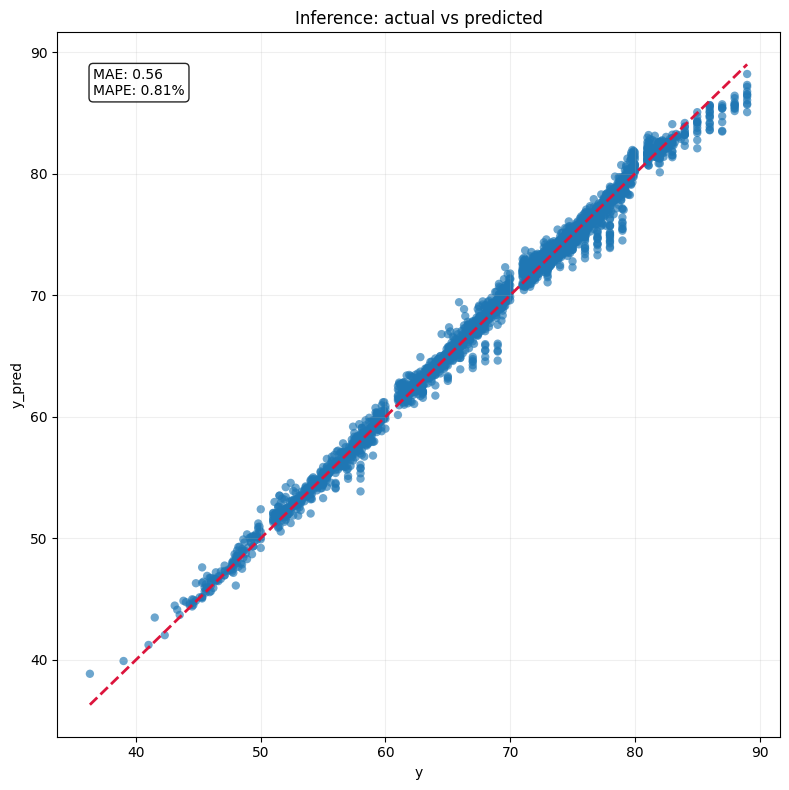

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

y_pred = best_model.predict(X)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred) * 100

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y, y_pred, alpha=0.65, edgecolors="none")

line_min = min(y.min(), y_pred.min())
line_max = max(y.max(), y_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="crimson", linewidth=2)

ax.set_title("Inference: actual vs predicted")
ax.set_xlabel("y")
ax.set_ylabel("y_pred")
ax.text(
    0.05,
    0.95,
    f"MAE: {mae:.2f}\nMAPE: {mape:.2f}%",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Hold-out test evaluation

In [10]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, y, groups=df["Country"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

X_train = train_df[[c for c in train_df.columns if c not in COLS_TO_DROP]]
y_train = train_df["Life expectancy "]
train_groups = train_df["Country"]

X_test = test_df[[c for c in test_df.columns if c not in COLS_TO_DROP]]
y_test = test_df["Life expectancy "]

train_df.shape, test_df.shape, train_groups.nunique(), test_df["Country"].nunique()

((2336, 22), (592, 22), 146, 37)

In [11]:
def objective_gpu_holdout(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
    }

    model = xgb.XGBRegressor(**param, device="cuda")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=GroupKFold(n_splits=3),
        groups=train_groups,
        scoring={
            "mae": "neg_mean_absolute_error",
            "mape": "neg_mean_absolute_percentage_error",
        },
        error_score="raise",
    )

    fold_mapes = -scores["test_mape"] * 100
    print(f"Fold MAPE (%): {fold_mapes}")
    print(f"Mean MAPE (%): {fold_mapes.mean():.2f}")

    return scores["test_mae"].mean()

In [12]:
# Create and run the optimization process with 10 trials on the training subset
study_holdout = optuna.create_study(study_name="xgboost_study_cuda_holdout", direction="maximize")
study_holdout.optimize(objective_gpu_holdout, n_trials=10, show_progress_bar=True, n_jobs=-1)

# Retrieve the best parameter values
best_params_holdout = study_holdout.best_params
print(f"\nBest parameters: {best_params_holdout}")

[I 2026-05-25 22:45:56,572] A new study created in memory with name: xgboost_study_cuda_holdout
Best trial: 5. Best value: -2.30157:  10%|█         | 1/10 [00:14<02:12, 14.71s/it]

Fold MAPE (%): [3.65528738 4.08995443 2.92201881]
Mean MAPE (%): 3.56
[I 2026-05-25 22:46:11,279] Trial 5 finished with value: -2.301574509518217 and parameters: {'max_depth': 9, 'learning_rate': 0.06202526775207519, 'n_estimators': 122, 'subsample': 0.503582856219476, 'colsample_bytree': 0.7890455961812106, 'min_child_weight': 3, 'gamma': 1.028040458826716}. Best is trial 5 with value: -2.301574509518217.


Best trial: 5. Best value: -2.30157:  20%|██        | 2/10 [00:22<01:26, 10.81s/it]

Fold MAPE (%): [3.60171521 4.00831081 3.05051189]
Mean MAPE (%): 3.55
[I 2026-05-25 22:46:19,365] Trial 0 finished with value: -2.30253409428391 and parameters: {'max_depth': 8, 'learning_rate': 0.060304628063686624, 'n_estimators': 464, 'subsample': 0.7563883673753042, 'colsample_bytree': 0.5908641610294378, 'min_child_weight': 1, 'gamma': 2.642995890366455}. Best is trial 5 with value: -2.301574509518217.


Best trial: 6. Best value: -2.21147:  30%|███       | 3/10 [00:23<00:43,  6.24s/it]

...

Fold MAPE (%): [3.51468937 4.01422516 3.04186411]
Mean MAPE (%): 3.52
[I 2026-05-25 22:46:27,228] Trial 3 finished with value: -2.288766603580678 and parameters: {'max_depth': 7, 'learning_rate': 0.0496203635722115, 'n_estimators': 437, 'subsample': 0.5732275228440276, 'colsample_bytree': 0.5917926177583117, 'min_child_weight': 6, 'gamma': 0.7457929037955102}. Best is trial 1 with value: -2.2026484562628936.


Best trial: 1. Best value: -2.20265:  90%|█████████ | 9/10 [00:31<00:01,  1.41s/it]

Fold MAPE (%): [3.59596776 3.84324796 2.97096894]
Mean MAPE (%): 3.47
[I 2026-05-25 22:46:27,818] Trial 2 finished with value: -2.252908323776154 and parameters: {'max_depth': 7, 'learning_rate': 0.02740462639681012, 'n_estimators': 411, 'subsample': 0.715408047672736, 'colsample_bytree': 0.6234958753700245, 'min_child_weight': 8, 'gamma': 0.3136519535564153}. Best is trial 1 with value: -2.2026484562628936.


Best trial: 1. Best value: -2.20265: 100%|██████████| 10/10 [00:31<00:00,  3.16s/it]

Fold MAPE (%): [3.68619767 4.06517655 2.7910676 ]
Mean MAPE (%): 3.51
[I 2026-05-25 22:46:28,125] Trial 8 finished with value: -2.268334199944321 and parameters: {'max_depth': 10, 'learning_rate': 0.0653339353675394, 'n_estimators': 988, 'subsample': 0.737812688442803, 'colsample_bytree': 0.9477210752424919, 'min_child_weight': 4, 'gamma': 2.378086628737897}. Best is trial 1 with value: -2.2026484562628936.

Best parameters: {'max_depth': 4, 'learning_rate': 0.029024845572517007, 'n_estimators': 587, 'subsample': 0.508902440184068, 'colsample_bytree': 0.7138965185968221, 'min_child_weight': 6, 'gamma': 4.806313089739527}


In [13]:
study_holdout.best_value

-2.2026484562628936

In [14]:
best_model_holdout = xgb.XGBRegressor(**best_params_holdout, device="cuda")
best_model_holdout.fit(X_train, y_train)
test_predictions = best_model_holdout.predict(X_test)
test_predictions[:: max(1, len(test_predictions) // 10)][:10], y_test.iloc[:: max(1, len(y_test) // 10)][:10], test_predictions.shape, y_test.shape

(array([74.80413 , 63.453327, 83.41913 , 72.2704  , 60.670628, 67.799385,
        64.8768  , 82.29385 , 77.40091 , 75.502716], dtype=float32),
 144     72.7
 299     64.2
 502     81.0
 819     73.3
 974     57.0
 1209    67.7
 1782    66.2
 1923    78.9
 2353    78.3
 2588    75.1
 Name: Life expectancy , dtype: float64,
 (592,),
 (592,))

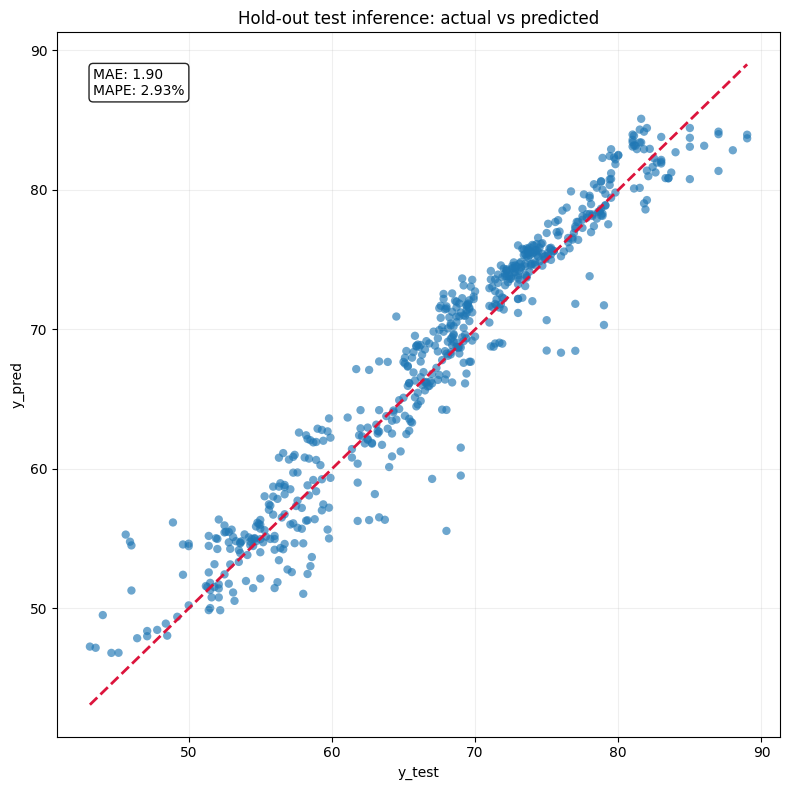

In [15]:
test_mae = mean_absolute_error(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions) * 100

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, test_predictions, alpha=0.65, edgecolors="none")

line_min = min(y_test.min(), test_predictions.min())
line_max = max(y_test.max(), test_predictions.max())
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="crimson", linewidth=2)

ax.set_title("Hold-out test inference: actual vs predicted")
ax.set_xlabel("y_test")
ax.set_ylabel("y_pred")
ax.text(
    0.05,
    0.95,
    f"MAE: {test_mae:.2f}\nMAPE: {test_mape:.2f}%",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()